# Week 5 — Embedding Space Exploration & COCO-Grounded Direction Vectors

**Option A: Controllable Synthesis & Editing | MSc Dissertation — Newcastle University**

> **Prerequisites:** week1_data_colab ✓  week3_baseline ✓  week4_prompts ✓

**What this does:**
1. Extract CLIP embeddings for all 1k images
2. t-SNE coloured by COCO category presence
3. Embedding interpolation between image pairs
4. COCO-grounded direction vectors (Fix 3 — novel contribution)

**Literature:** Radford et al. (2021) CLIP · Suzuki & Matsuo (2022) · Liu et al. (2023)

**Run order every session:** Cell 1 → Cell 2 → Cell 3 → Cell 4 onwards


In [1]:
# ── CELL 1 — Mount Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [2]:
# ── CELL 2 — Install packages ─────────────────────────────────────────────
!pip install -q --upgrade accelerate scikit-learn
!pip install -q sentencepiece
import transformers
print(f'transformers: {transformers.__version__}')
print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 104.4 MB/s eta 0:00:00
transformers: 5.0.0
Ready.


In [3]:
# ── CELL 3 — Paths ────────────────────────────────────────────────────────
import os

BASE           = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR  = f'{BASE}/data/processed'
COCO_INST_FILE = f'{BASE}/data/coco/annotations/instances_val2017.json'
RESULTS_DIR    = f'{BASE}/results'
STEER_STRENGTH = 0.3

os.makedirs(RESULTS_DIR, exist_ok=True)

print('Required files check:')
for f in [f'{PROCESSED_DIR}/test.csv', f'{RESULTS_DIR}/week3_baseline.csv']:
    ok = os.path.exists(f)
    print(f'  {"OK" if ok else "MISSING"} : {os.path.basename(f)}')
print('Proceed to Cell 4.')

Required files check:
  OK : test.csv
  OK : week3_baseline.csv
Proceed to Cell 4.


In [4]:
# ── CELL 4 — Imports ──────────────────────────────────────────────────────
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
from sklearn.manifold import TSNE
from transformers import CLIPProcessor, CLIPModel

print('All imports done.')

All imports done.


In [5]:
# ── CELL 5 — Load CLIP ────────────────────────────────────────────────────
# CLIP provides the shared 512-dim embedding space (Radford et al., 2021)
# This is the practical realisation of Suzuki & Matsuo's (2022)
# theoretical 'shared representation' concept.

CLIP_MODEL_ID = 'openai/clip-vit-base-patch32'
print(f'Loading CLIP: {CLIP_MODEL_ID}')
clip_proc  = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID)
dev        = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model = clip_model.to(dev).eval()
print(f'CLIP loaded on {dev}.')

Loading CLIP: openai/clip-vit-base-patch32


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


CLIP loaded on cuda.


In [6]:
# ── CELL 6 — Load test data ───────────────────────────────────────────────
test_df = pd.read_csv(f'{PROCESSED_DIR}/test.csv')
print(f'Test split: {len(test_df)} images')
print(test_df[['image_id','img_path','captions']].head(2).to_string())

Test split: 100 images
   image_id                                                                      img_path                                                                                                                                                                                                                                           captions
0    577864  /content/drive/MyDrive/dissertation_final/data/coco/val2017/000000577864.jpg  Three people are playing with a red kick ball. | 3 People in a dirt field playing soccer. | Three people are kicking around an orange ball. | Three people playing ball game on sandy ground.  | a couple of people are kicking a ball in a field
1    238013  /content/drive/MyDrive/dissertation_final/data/coco/val2017/000000238013.jpg           A man is playing tennis, the ball is coming toward him. | A man about to hit a tennis ball. | A man is preparing to hit a tennis ball.  | A man prepares to hit a tennis ball | The sun shines as the man plays ten

In [7]:
# ── CELL 7 — Extract CLIP embeddings ─────────────────────────────────────
# L2-normalised following Radford et al. (2021) — cosine similarity
# in the unit hypersphere is the correct distance metric.

def extract_embeddings(df, batch_size=16):
    img_embs, txt_embs = [], []
    for i in tqdm(range(0, len(df), batch_size), desc='Extracting CLIP embeddings'):
        batch    = df.iloc[i:i+batch_size]
        images   = [Image.open(p).convert('RGB') for p in batch['img_path']]
        captions = [c.split(' | ')[0] for c in batch['captions']]
        inputs   = clip_proc(text=captions, images=images, return_tensors='pt',
                             padding=True, truncation=True, max_length=77)
        inputs   = {k: v.to(dev) for k, v in inputs.items()}
        with torch.no_grad():
            out   = clip_model(**inputs)
            i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
            t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
        img_embs.append(i_emb.cpu().numpy())
        txt_embs.append(t_emb.cpu().numpy())
    return np.vstack(img_embs), np.vstack(txt_embs)

img_embs, txt_embs = extract_embeddings(test_df)
np.save(f'{RESULTS_DIR}/week5_img_embeddings.npy', img_embs)
np.save(f'{RESULTS_DIR}/week5_txt_embeddings.npy', txt_embs)
print(f'Image embeddings: {img_embs.shape}')
print(f'Text embeddings : {txt_embs.shape}')
print('Saved to Drive.')


Extracting CLIP embeddings: 100%|██████████| 7/7 [01:02<00:00,  8.88s/it]

Image embeddings: (100, 512)
Text embeddings : (100, 512)
Saved to Drive.


In [8]:
# ── CELL 8 — Load COCO category sets (Fix 3) ─────────────────────────────
# Grounds direction vectors in actual COCO annotations rather than
# heuristic text pairs — Suzuki & Matsuo (2022) requirement.

def load_coco_category_sets(df):
    if not os.path.exists(COCO_INST_FILE):
        print(f'instances_val2017.json not found at {COCO_INST_FILE}')
        return {}
    print('Loading COCO instance annotations...')
    with open(COCO_INST_FILE) as f:
        inst = json.load(f)
    cat_map      = {c['id']: c['name'] for c in inst['categories']}
    sampled_ids  = set(df['image_id'].tolist())
    cat_sets     = defaultdict(set)
    for ann in inst['annotations']:
        if ann['image_id'] in sampled_ids:
            cat_sets[cat_map[ann['category_id']]].add(ann['image_id'])
    top5 = sorted(cat_sets.items(), key=lambda x: len(x[1]), reverse=True)[:5]
    print(f'Top 5 categories: {[(c, len(s)) for c, s in top5]}')
    return dict(cat_sets)

cat_image_ids = load_coco_category_sets(test_df)
print(f'Categories loaded: {len(cat_image_ids)}')

Loading COCO instance annotations...
Top 5 categories: [('person', 54), ('car', 12), ('chair', 11), ('cup', 9), ('dining table', 9)]
Categories loaded: 70


Running t-SNE (~2 min)...


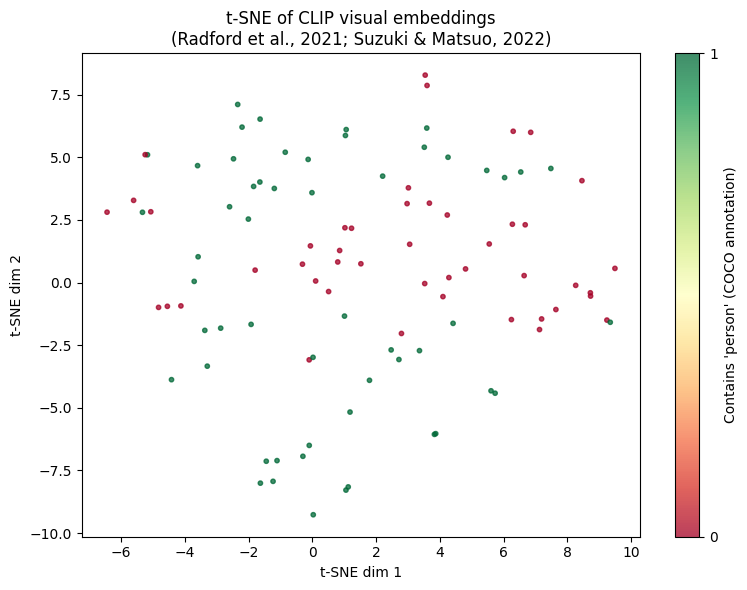

Saved: /content/drive/MyDrive/dissertation_final/results/week5_tsne_embeddings.png


In [10]:
print('Running t-SNE (~2 min)...')
n_samples  = min(500, len(img_embs))
idx        = np.random.choice(len(img_embs), n_samples, replace=False)
embs_sub   = img_embs[idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
proj = tsne.fit_transform(embs_sub)

has_person = np.array([
    1 if test_df.iloc[i]['image_id'] in cat_image_ids.get('person', set()) else 0
    for i in idx
])

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(proj[:,0], proj[:,1], c=has_person, cmap='RdYlGn', s=10, alpha=0.75)
plt.colorbar(sc, ax=ax, ticks=[0,1], label="Contains 'person' (COCO annotation)")
ax.set_title('t-SNE of CLIP visual embeddings\n(Radford et al., 2021; Suzuki & Matsuo, 2022)')
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
plt.tight_layout()
out = f'{RESULTS_DIR}/week5_tsne_embeddings.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [11]:
# ── CELL 10 — Embedding interpolation ────────────────────────────────────
# Demonstrates CLIP embedding space is continuous (Suzuki & Matsuo, 2022)

print('Running embedding interpolation demo...')
records = []
for pair_idx in range(3):
    idx_a, idx_b = np.random.choice(len(test_df), 2, replace=False)
    emb_a, emb_b = img_embs[idx_a], img_embs[idx_b]
    for step, alpha in enumerate(np.linspace(0, 1, 5)):
        emb     = (1-alpha)*emb_a + alpha*emb_b
        emb     = emb / np.linalg.norm(emb)
        sims    = img_embs @ emb
        nearest = int(np.argmax(sims))
        records.append({
            'pair': pair_idx, 'step': step, 'alpha': round(float(alpha), 2),
            'nearest_id': test_df.iloc[nearest]['image_id'],
            'nearest_caption': test_df.iloc[nearest]['captions'].split(' | ')[0],
            'similarity': round(float(sims[nearest]), 4),
        })
    print(f'  Pair {pair_idx+1}: {test_df.iloc[idx_a]["image_id"]} -> {test_df.iloc[idx_b]["image_id"]}')

interp_df = pd.DataFrame(records)
interp_df.to_csv(f'{RESULTS_DIR}/week5_interpolation.csv', index=False)
print(interp_df[['pair','alpha','nearest_caption']].to_string(index=False))

Running embedding interpolation demo...
  Pair 1: 184324 -> 412286
  Pair 2: 356531 -> 429109
  Pair 3: 363784 -> 359677
 pair  alpha                                                          nearest_caption
    0   0.00                     A group of people walking across a busy city street.
    0   0.25                     A group of people walking across a busy city street.
    0   0.50                   A man swinging a tennis racquet towards a tennis ball.
    0   0.75                   A man swinging a tennis racquet towards a tennis ball.
    0   1.00                   A man swinging a tennis racquet towards a tennis ball.
    1   0.00 a woman siting at a restaurant table with a plate of mexican food on it 
    1   0.25 a woman siting at a restaurant table with a plate of mexican food on it 
    1   0.50 a woman siting at a restaurant table with a plate of mexican food on it 
    1   0.75                              A street filled with buses and a white van.
    1   1.00       

In [12]:
# ── CELL 11 — COCO-grounded direction vectors (Fix 3) ────────────────────
# Direction = mean(WITH category) - mean(WITHOUT category)
# Principled: grounded in dataset annotations, not heuristic text pairs

def compute_coco_direction(img_embeddings, df, category_name, cat_image_ids):
    if category_name not in cat_image_ids:
        print(f'Category {category_name} not found.')
        return None
    with_ids    = cat_image_ids[category_name]
    without_ids = set(df['image_id'].tolist()) - with_ids
    with_mask   = df['image_id'].isin(with_ids).values
    wo_mask     = df['image_id'].isin(without_ids).values
    if with_mask.sum() < 5 or wo_mask.sum() < 5:
        print(f'Insufficient samples for {category_name}.')
        return None
    direction = img_embeddings[with_mask].mean(0) - img_embeddings[wo_mask].mean(0)
    direction = direction / np.linalg.norm(direction)
    print(f'  Direction computed: {category_name} | WITH={with_mask.sum()} WITHOUT={wo_mask.sum()}')
    return direction

def steer_embedding(emb, direction, strength=STEER_STRENGTH):
    steered = emb + strength * direction
    return steered / np.linalg.norm(steered)

# Test on target categories
print('Computing COCO-grounded direction vectors...')
directions = {}
for cat in ['person', 'car', 'dog', 'cat', 'chair']:
    d = compute_coco_direction(img_embs, test_df, cat, cat_image_ids)
    if d is not None:
        directions[cat] = d
print(f'\nDirections computed for: {list(directions.keys())}')

Computing COCO-grounded direction vectors...
  Direction computed: person | WITH=54 WITHOUT=46
  Direction computed: car | WITH=12 WITHOUT=88
Insufficient samples for dog.
Category cat not found.
  Direction computed: chair | WITH=11 WITHOUT=89

Directions computed for: ['person', 'car', 'chair']


In [13]:
# ── CELL 12 — Attribute steering demo ────────────────────────────────────
print('Running COCO-grounded attribute steering...')
sample_df = test_df.sample(20, random_state=42).reset_index(drop=True)
records   = []

for cat_name, direction in directions.items():
    for i, (_, row) in enumerate(sample_df.iterrows()):
        orig_idx  = test_df.index[test_df['image_id'] == row['image_id']]
        if len(orig_idx) == 0: continue
        orig_emb    = img_embs[orig_idx[0]]
        steered_emb = steer_embedding(orig_emb, direction)
        orig_near   = int(np.argmax(img_embs @ orig_emb))
        steer_near  = int(np.argmax(img_embs @ steered_emb))
        records.append({
            'category_direction': f'-> {cat_name}',
            'image_id':           row['image_id'],
            'original_caption':   test_df.iloc[orig_near]['captions'].split(' | ')[0],
            'steered_caption':    test_df.iloc[steer_near]['captions'].split(' | ')[0],
            'caption_changed':    orig_near != steer_near,
            'moved_toward_cat':   test_df.iloc[steer_near]['image_id'] in cat_image_ids.get(cat_name, set()),
        })

steer_df = pd.DataFrame(records)
steer_df.to_csv(f'{RESULTS_DIR}/week5_attribute_steering.csv', index=False)
print('\nSteering results:')
print(steer_df.groupby('category_direction')[['caption_changed','moved_toward_cat']].mean().round(2).to_string())

Running COCO-grounded attribute steering...

Steering results:
                    caption_changed  moved_toward_cat
category_direction                                   
-> car                          0.0              0.15
-> chair                        0.0              0.10
-> person                       0.0              0.60


In [14]:
# ── CELL 13 — Final verification ──────────────────────────────────────────
print('='*55)
print('Week 5 — Final verification')
print('='*55)
for f in [f'{RESULTS_DIR}/week5_img_embeddings.npy',
          f'{RESULTS_DIR}/week5_txt_embeddings.npy',
          f'{RESULTS_DIR}/week5_tsne_embeddings.png',
          f'{RESULTS_DIR}/week5_interpolation.csv',
          f'{RESULTS_DIR}/week5_attribute_steering.csv']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(f):40s} {size:>10,} bytes')
print()
print('Week 5 complete. Next: week6_embedding_eval_colab.ipynb')
print(f'Directions available for week 6: {list(directions.keys())}')

Week 5 — Final verification
  [OK] week5_img_embeddings.npy                    204,928 bytes
  [OK] week5_txt_embeddings.npy                    204,928 bytes
  [OK] week5_tsne_embeddings.png                    80,842 bytes
  [OK] week5_interpolation.csv                       1,204 bytes
  [OK] week5_attribute_steering.csv                  8,304 bytes

Week 5 complete. Next: week6_embedding_eval_colab.ipynb
Directions available for week 6: ['person', 'car', 'chair']
